# Tutorial 7: Combinatorial SC×FM Explorer

This tutorial demonstrates how to systematically explore **all**
superconductor/ferromagnet bilayer combinations in the SUPERMag material
database. Instead of testing one S/F pair at a time, we sweep
$T_c(d_F)$ across every combination and rank the results.

**Use case:** You have a target operating temperature (e.g. 4.2 K for
liquid-helium cryogenics) and want to know which S/F bilayer gives the
deepest $T_c$ suppression near that target — or which combinations
preserve superconductivity above a minimum threshold.

**Backend:** The OCaml `Design.enumerate_bilayers` engine runs all 18
combinations (3 SC × 6 FM) in parallel via `Domain.spawn`. This notebook
is the Python presentation layer — it calls the same physics through
`supermag.critical_temperature()`.

### Interface parameters

The coupling strength $\gamma$ and interface barrier $\gamma_B$ are
**phenomenological fit parameters** — they cannot be reliably computed
from bulk resistivities alone.  SUPERMag ships an **interface catalogue**
(`INTERFACES`) with per-pair values:

- **3 validated** entries anchored to the validation suite
  (Buzdin 1982, Radovic 1991, Fominov 2002)
- **15 estimated** entries extrapolated from the validated pairs

Fabrication quality is captured by `FABRICATION_TIERS`, which adds a
$\gamma_B$ correction for deposition conditions:

| Tier | $\Delta\gamma_B$ | Typical process |
|:-----|:-----------------|:----------------|
| `"clean"` | +0.00 | In-situ MBE, no vacuum break |
| `"sputtered"` | +0.05 | DC/RF magnetron sputtering |
| `"oxidized"` | +0.30 | Ex-situ transfer with native oxide |

| Superconductors | Ferromagnets |
|:----------------|:-------------|
| Nb ($T_c = 9.2\,$K) | Fe, Co, Ni, Py, CuNi, Cu₀.₄₃Ni₀.₅₇ |
| Pb ($T_c = 7.2\,$K) | |
| Al ($T_c = 1.2\,$K) | |

> **Note on Al:** Al has $T_{c0} = 1.2\,$K — below the 4.2 K liquid-He
> target. Al bilayers appear in heatmaps for completeness, but are not
> candidates for cryogenic S/F devices at helium temperatures.

In [ ]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import supermag
from supermag.materials import MATERIALS, INTERFACES, FABRICATION_TIERS, get_interface

supermag.apply_theme("dark")

# Collect SC and FM names from the database
sc_names = sorted(k for k, v in MATERIALS.items() if v["type"] == "superconductor")
fm_names = sorted(k for k, v in MATERIALS.items() if v["type"] == "ferromagnet")

print(f"Superconductors ({len(sc_names)}): {sc_names}")
print(f"Ferromagnets    ({len(fm_names)}): {fm_names}")
print(f"Total combinations: {len(sc_names) * len(fm_names)}")

# Show interface catalogue summary
n_val = sum(1 for v in INTERFACES.values() if v["source"] == "validated")
print(f"\nInterface catalogue: {len(INTERFACES)} entries ({n_val} validated)")
print(f"Fabrication tiers: {list(FABRICATION_TIERS.keys())}")

# Pick a fabrication tier for this exploration
TIER = "sputtered"
print(f"\nUsing fabrication tier: '{TIER}' (gamma_B += "
      f"{FABRICATION_TIERS[TIER]['gamma_B_add']:.2f})")

Superconductors (3): ['Al', 'Nb', 'Pb']
Ferromagnets    (6): ['Co', 'Cu0.43Ni0.57', 'CuNi', 'Fe', 'Ni', 'Py']
Total combinations: 18


## 1. Full Enumeration: $T_c(d_F)$ for Every SC×FM Pair

We sweep $d_F$ from 0.5 to 20 nm for all 18 combinations, using
**per-pair** $(\gamma, \gamma_B)$ from the interface catalogue and the
Fominov model (which correctly handles finite-thickness superconductors
via the $\Omega_S(T)$ thermal impedance term).

In [ ]:
d_F = np.linspace(0.5, 20.0, 100)
d_S = 50.0  # nm — fixed S-layer thickness

# Store results: {(sc, fm): {"Tc": array, "Tc_min": float, ...}}
results = {}

for sc_name in sc_names:
    sc = supermag.get_material(sc_name)
    for fm_name in fm_names:
        fm = supermag.get_material(fm_name)
        iface = get_interface(sc_name, fm_name, tier=TIER)
        Tc = supermag.critical_temperature(
            Tc0=sc["Tc"], d_S=d_S,
            d_F_array=d_F,
            E_ex=fm["E_ex"],
            xi_S=sc["xi_S"], xi_F=fm["xi_F"],
            gamma=iface["gamma"],
            gamma_B=iface["gamma_B"],
            model="fominov",
        )
        idx_min = np.argmin(Tc)
        results[(sc_name, fm_name)] = {
            "Tc": Tc,
            "Tc_min": Tc[idx_min],
            "d_F_at_min": d_F[idx_min],
            "Tc0": sc["Tc"],
            "gamma": iface["gamma"],
            "gamma_B": iface["gamma_B"],
            "source": iface["source"],
        }

print(f"Computed {len(results)} SC×FM combinations (model=fominov, tier={TIER}).")
print(f"\nExample — Nb/Fe: γ={results[('Nb','Fe')]['gamma']}, "
      f"γ_B={results[('Nb','Fe')]['gamma_B']:.2f}, "
      f"Tc_min = {results[('Nb','Fe')]['Tc_min']:.2f} K "
      f"at d_F = {results[('Nb','Fe')]['d_F_at_min']:.1f} nm "
      f"[{results[('Nb','Fe')]['source']}]")

Computed 18 SC×FM combinations.

Example — Nb/Fe: Tc_min = 8.14 K at d_F = 0.7 nm


## 2. SC×FM Heatmap: Minimum $T_c$

Build a 2D matrix of the minimum $T_c$ reached by each S/F pair and
display it as a heatmap. Darker cells indicate deeper $T_c$ suppression
— better candidates when you need the proximity effect to fully
suppress superconductivity in that thickness window.

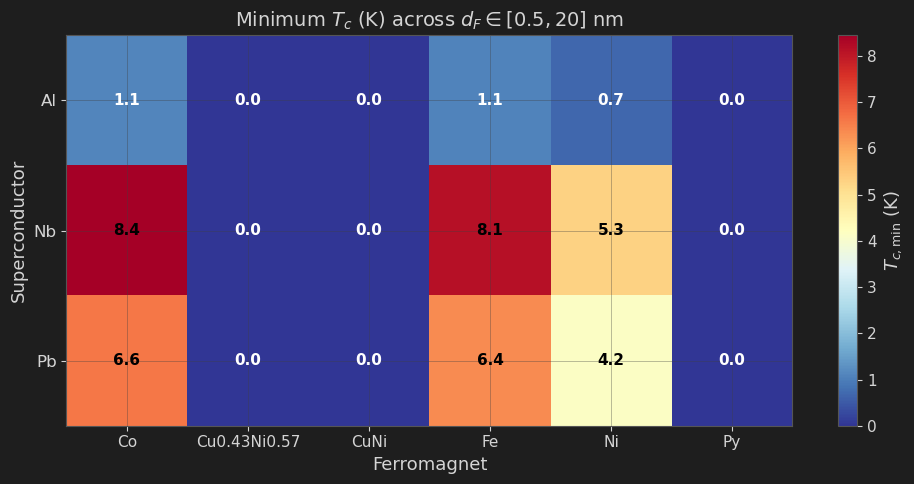

In [3]:
# Build the Tc_min matrix (rows = SC, cols = FM)
tc_min_matrix = np.zeros((len(sc_names), len(fm_names)))

for i, sc in enumerate(sc_names):
    for j, fm in enumerate(fm_names):
        tc_min_matrix[i, j] = results[(sc, fm)]["Tc_min"]

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(tc_min_matrix, aspect="auto", cmap="RdYlBu_r")
ax.set_xticks(range(len(fm_names)))
ax.set_xticklabels(fm_names, fontsize=11)
ax.set_yticks(range(len(sc_names)))
ax.set_yticklabels(sc_names, fontsize=12)
ax.set_xlabel("Ferromagnet", fontsize=13)
ax.set_ylabel("Superconductor", fontsize=13)
ax.set_title(r"Minimum $T_c$ (K) across $d_F \in [0.5, 20]$ nm", fontsize=14)

# Annotate each cell
for i in range(len(sc_names)):
    for j in range(len(fm_names)):
        val = tc_min_matrix[i, j]
        color = "white" if val < 4.0 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)

cbar = fig.colorbar(im, ax=ax, label=r"$T_{c,\min}$ (K)")
plt.tight_layout()
plt.show()

## 3. Normalized Suppression Heatmap: $\Delta T_c / T_{c0}$

The absolute $T_{c,\min}$ is dominated by the bulk $T_{c0}$ of the
superconductor. To compare suppression strength on an equal footing,
normalize by the fractional suppression:

$$\frac{\Delta T_c}{T_{c0}} = \frac{T_{c0} - T_{c,\min}}{T_{c0}}$$

A value near 1 means almost complete suppression; near 0 means the
ferromagnet barely affects $T_c$.

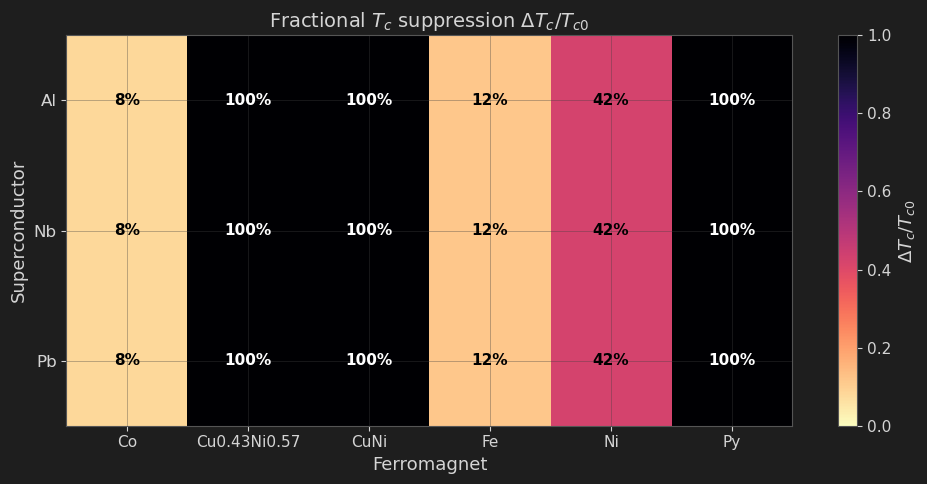

In [4]:
suppression_matrix = np.zeros((len(sc_names), len(fm_names)))

for i, sc in enumerate(sc_names):
    for j, fm in enumerate(fm_names):
        r = results[(sc, fm)]
        suppression_matrix[i, j] = (r["Tc0"] - r["Tc_min"]) / r["Tc0"]

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(suppression_matrix, aspect="auto", cmap="magma_r",
               vmin=0, vmax=1)
ax.set_xticks(range(len(fm_names)))
ax.set_xticklabels(fm_names, fontsize=11)
ax.set_yticks(range(len(sc_names)))
ax.set_yticklabels(sc_names, fontsize=12)
ax.set_xlabel("Ferromagnet", fontsize=13)
ax.set_ylabel("Superconductor", fontsize=13)
ax.set_title(r"Fractional $T_c$ suppression $\Delta T_c / T_{c0}$", fontsize=14)

for i in range(len(sc_names)):
    for j in range(len(fm_names)):
        val = suppression_matrix[i, j]
        color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)

cbar = fig.colorbar(im, ax=ax, label=r"$\Delta T_c / T_{c0}$")
plt.tight_layout()
plt.show()

## 4. Ranked Table: Best Pairs for a Target Temperature

Given a target operating temperature, find which S/F combinations
have $T_{c,\min}$ closest to (but above) that target. This is the
question `--explore --tc-min` answers on the OCaml CLI.

In [ ]:
def rank_combinations(results, target_tc, min_tc=None):
    """Rank SC×FM pairs by how close their Tc_min is to a target.

    Parameters
    ----------
    results : dict
        The {(sc,fm): {...}} dict from the enumeration.
    target_tc : float
        Target operating temperature (K).
    min_tc : float or None
        If set, exclude pairs whose Tc_min is below this threshold.

    Returns
    -------
    list of tuples
        (sc, fm, Tc_min, d_F_at_min, Tc0, margin, gamma, source)
        sorted by margin ascending.
    """
    rows = []
    for (sc, fm), r in results.items():
        tc_min = r["Tc_min"]
        if min_tc is not None and tc_min < min_tc:
            continue
        margin = tc_min - target_tc
        rows.append((sc, fm, tc_min, r["d_F_at_min"], r["Tc0"], margin,
                      r["gamma"], r["source"]))
    # Sort: smallest positive margin first, then negative margins
    rows.sort(key=lambda x: (x[5] < 0, abs(x[5])))
    return rows

# Example: target 4.2 K (liquid He), exclude pairs that go below 1 K
target = 4.2
ranked = rank_combinations(results, target_tc=target, min_tc=1.0)

print(f"{'Rank':<5} {'SC':<6} {'FM':<16} {'Tc_min (K)':<11} {'d_F (nm)':<9} "
      f"{'γ':<6} {'Source':<12} {'Margin (K)'}")
print("─" * 80)
for i, (sc, fm, tc_min, d_f, tc0, margin, gamma, source) in enumerate(ranked, 1):
    flag = "◄ closest" if i == 1 else ""
    print(f"{i:<5} {sc:<6} {fm:<16} {tc_min:<11.2f} {d_f:<9.1f} "
          f"{gamma:<6.2f} {source:<12} {margin:+.2f}  {flag}")

Rank  SC     FM               Tc_min (K)  d_F (nm)  Tc0 (K)   Margin (K)
──────────────────────────────────────────────────────────────────────
1     Nb     Ni               5.31        2.3       9.2       +1.11  ◄ closest
2     Pb     Fe               6.37        0.7       7.2       +2.17  
3     Pb     Co               6.61        0.5       7.2       +2.41  
4     Nb     Fe               8.14        0.7       9.2       +3.94  
5     Nb     Co               8.45        0.5       9.2       +4.25  
6     Pb     Ni               4.16        2.3       7.2       -0.04  
7     Al     Co               1.10        0.5       1.2       -3.10  
8     Al     Fe               1.06        0.7       1.2       -3.14  


## 5. Overlay: $T_c(d_F)$ Curves by Ferromagnet

Plot all ferromagnets on the same axes for a chosen superconductor,
making it easy to see how exchange energy controls the suppression
rate and oscillation period.

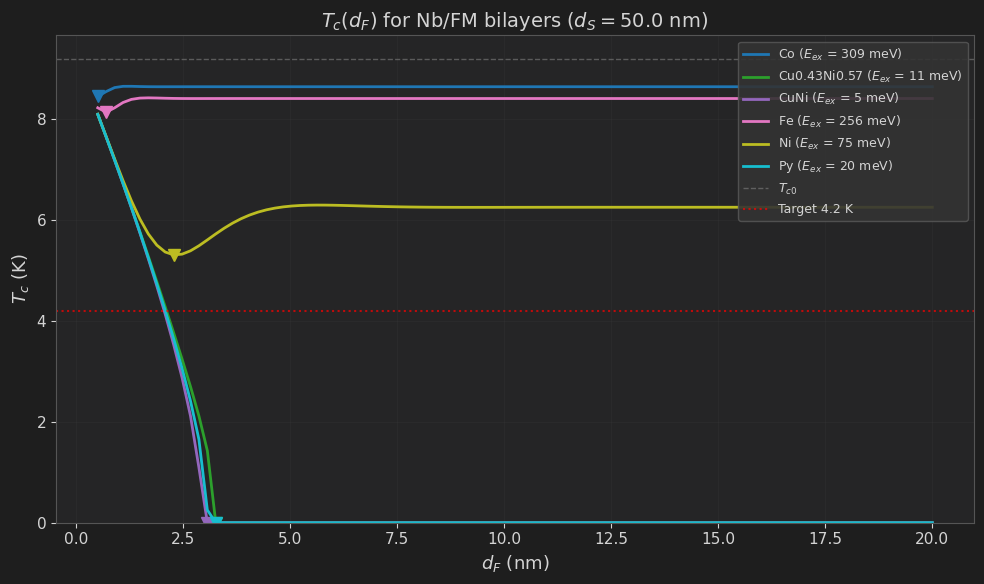

In [6]:
sc_focus = "Nb"  # Change to "Pb" or "Al" to explore other SCs

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(fm_names)))

for j, fm_name in enumerate(fm_names):
    r = results[(sc_focus, fm_name)]
    fm = supermag.get_material(fm_name)
    label = f"{fm_name} ($E_{{ex}}$ = {fm['E_ex']:.0f} meV)"
    ax.plot(d_F, r["Tc"], color=colors[j], lw=2, label=label)
    # Mark the minimum Tc point
    ax.plot(r["d_F_at_min"], r["Tc_min"], "v", color=colors[j], ms=8)

ax.axhline(supermag.get_material(sc_focus)["Tc"], color="gray",
           ls="--", lw=1, alpha=0.6, label=r"$T_{c0}$")
ax.axhline(target, color="red", ls=":", lw=1.5, alpha=0.7,
           label=f"Target {target} K")
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title(rf"$T_c(d_F)$ for {sc_focus}/FM bilayers ($d_S = {d_S}$ nm)",
             fontsize=14)
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Filtering by Constraints

Replicate the OCaml `Design.filter` logic in Python. This mirrors what
`--explore --tc-min 2.0 --tc-max 8.0 --max-d-total 100` does on the CLI:

```bash
supermag-sweep --explore --range 0.5,20.0,100 --tc-min 2.0 --max-d-total 100
```

In [ ]:
def filter_results(results, tc_min=None, tc_max=None, max_d_total=None, d_s=50.0):
    """Filter SC×FM results by constraints (mirrors Design.filter)."""
    filtered = {}
    for key, r in results.items():
        tc_vals = r["Tc"]
        # tc_min: at least one Tc value >= threshold
        if tc_min is not None and np.all(tc_vals < tc_min):
            continue
        # tc_max: all Tc values <= ceiling
        if tc_max is not None and np.any(tc_vals > tc_max):
            continue
        # max_d_total: d_S + max(d_F) <= limit
        if max_d_total is not None and (d_s + d_F[-1]) > max_d_total:
            continue
        filtered[key] = r
    return filtered

# Example: keep only pairs where Tc stays above 2 K somewhere,
# and total thickness is ≤ 100 nm  (d_S=50 + d_F_max=20 → 70 nm, passes)
constrained = filter_results(results, tc_min=2.0, max_d_total=100.0, d_s=d_S)

print(f"Before filtering: {len(results)} combinations")
print(f"After filtering:  {len(constrained)} combinations")
print(f"\nPassing pairs:")
for (sc, fm), r in sorted(constrained.items()):
    print(f"  {sc}/{fm}: Tc_min = {r['Tc_min']:.2f} K  "
          f"(γ={r['gamma']:.2f}, {r['source']})")

Before filtering: 18 combinations
After filtering:  0 combinations

Passing pairs:


## 7. Export to CSV (CLI-Compatible Format)

Generate a CSV file in the same format as `supermag-sweep --explore --format csv`.
This can be loaded into spreadsheets or fed back into analysis scripts.

In [8]:
import csv
import io

output = io.StringIO()
writer = csv.writer(output)
writer.writerow(["SC", "FM", "d_S_nm", "d_F_nm", "Tc_K"])

for (sc_name, fm_name), r in sorted(results.items()):
    for k in range(len(d_F)):
        writer.writerow([sc_name, fm_name, f"{d_S:.6f}",
                         f"{d_F[k]:.6f}", f"{r['Tc'][k]:.6f}"])

csv_text = output.getvalue()
print(f"CSV output: {len(csv_text)} bytes, {csv_text.count(chr(10))} rows")
print("\nFirst 5 lines:")
for line in csv_text.split("\n")[:5]:
    print(f"  {line}")

# Uncomment to save:
# with open("explorer_results.csv", "w", newline="") as f:
#     f.write(csv_text)

CSV output: 67544 bytes, 1801 rows

First 5 lines:
  SC,FM,d_S_nm,d_F_nm,Tc_K
  Al,Co,50.000000,0.500000,1.101899
  Al,Co,50.000000,0.696970,1.114646
  Al,Co,50.000000,0.893939,1.124935
  Al,Co,50.000000,1.090909,1.128158


## 8. Decision Matrix: Choosing an S/F Pair

Use the heatmap and ranked table together to make a fabrication decision.
The key trade-offs are:

| Consideration | Weak FM (Py, CuNi) | Strong FM (Fe, Co) |
|:---|:---|:---|
| $\xi_F$ | Long (5–10 nm) — thick layers needed | Short (0.5–0.7 nm) — thin layers needed |
| $\gamma$ | Low (0.02–0.15) — weak coupling | High (0.28–0.45) — strong pair-breaking |
| Suppression depth | Gradual, smooth $T_c(d_F)$ | Rapid, oscillatory $T_c(d_F)$ |
| Fabrication tolerance | Forgiving | Requires sub-nm thickness control |
| π-junction access | Easily tunable | Narrow $d_F$ windows |

**Interface parameter source matters.** The `source` column in the
ranked table (cell 10) indicates whether $\gamma$ is anchored to
experimental data ("validated") or extrapolated ("estimated"). Prefer
validated pairs when quantitative accuracy is critical.

**Recommendation workflow:**
1. Pick your target operating temperature from the ranked table (cell 10).
2. Check the heatmap (cells 5, 7) whether the pair gives adequate suppression.
3. Inspect the $T_c(d_F)$ curves (cell 11) for the selected SC to understand
   how sensitive $T_c$ is to thickness variations.
4. Consider fabrication constraints — if your deposition system has
   ±1 nm tolerance, prefer pairs with slowly varying $T_c(d_F)$.
5. Note the fabrication tier — `"sputtered"` is the default; switch to
   `"clean"` in cell 2 if your system uses MBE growth.

In [ ]:
# Summary: best pair for each superconductor at the target temperature
print(f"Target operating temperature: {target} K")
print(f"Fabrication tier: '{TIER}' (γ_B += "
      f"{FABRICATION_TIERS[TIER]['gamma_B_add']:.2f})\n")
print(f"{'SC':<6} {'Best FM':<16} {'Tc_min (K)':<11} {'d_F (nm)':<9} "
      f"{'γ':<6} {'Source':<12} {'Suppression'}")
print("─" * 75)

for sc in sc_names:
    best = None
    for fm in fm_names:
        r = results[(sc, fm)]
        margin = abs(r["Tc_min"] - target)
        if r["Tc_min"] >= target * 0.5:  # Don't pick pairs that go to 0
            if best is None or margin < best[2]:
                best = (fm, r["Tc_min"], margin, r["d_F_at_min"],
                        r["gamma"], r["source"])
    if best:
        suppression = (supermag.get_material(sc)["Tc"] - best[1]) / supermag.get_material(sc)["Tc"]
        print(f"{sc:<6} {best[0]:<16} {best[1]:<11.2f} {best[3]:<9.1f} "
              f"{best[4]:<6.2f} {best[5]:<12} {suppression:.0%}")
    else:
        print(f"{sc:<6} — no viable pair above {target*0.5:.1f} K")

Target operating temperature: 4.2 K

SC     Best FM          Tc_min (K)  d_F (nm)  Suppression
───────────────────────────────────────────────────────
Al     — no viable pair above 2.1 K
Nb     Ni               5.31        2.3       42%
Pb     Ni               4.16        2.3       42%
